In [ ]:
# Line Plots / Multi-panel Charts: This is your initial thought and a perfectly valid one.
# You can plot different EEG/ECG channels as separate lines on a single graph,
# or create multi-panel charts where each panel represents a different channel or a different time window.
# Ensure clear axis labels (time, amplitude/voltage) and potentially add markers for significant events if applicable.

# Spectrograms (Time-Frequency Plots): This is highly recommended for
# physiological signals like EEG and ECG. Spectrograms show how the frequency
# content of a signal changes over time. For EEG, this can reveal important brainwave activity
#  (delta, theta, alpha, beta, gamma bands). For ECG, it can highlight heart rate variability
#  and other cardiac dynamics. Tools like scipy.signal.spectrogram in Python can generate these.

# Wavelet Transforms: Similar to spectrograms, wavelet transforms can provide
# a more localized view of frequency content in time. Different wavelets can be
# chosen to highlight specific features in your signals.

In [2]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 45.0 MB/s eta 0:00:00


Extracting EDF parameters from /content/drive/MyDrive/MEng/6.S985/ds005873/sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-01_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 16721663  =      0.000 ... 65318.996 secs...
Extracting EDF parameters from /content/drive/MyDrive/MEng/6.S985/ds005873/sub-001/ses-01/ecg/sub-001_ses-01_task-szMonitoring_run-01_ecg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 16721663  =      0.000 ... 65318.996 secs...
Using matplotlib as 2D backend.


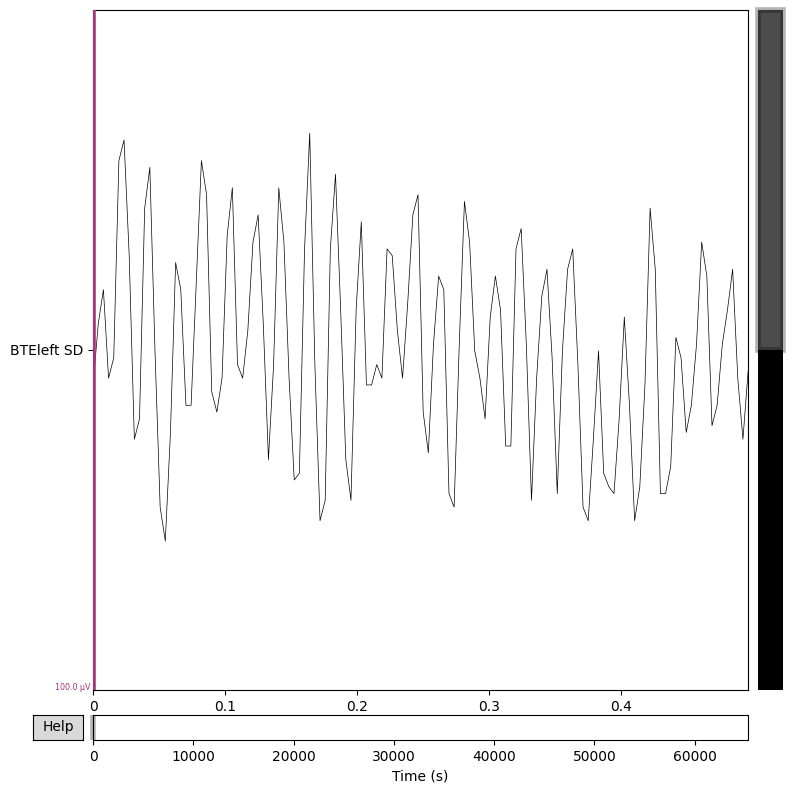

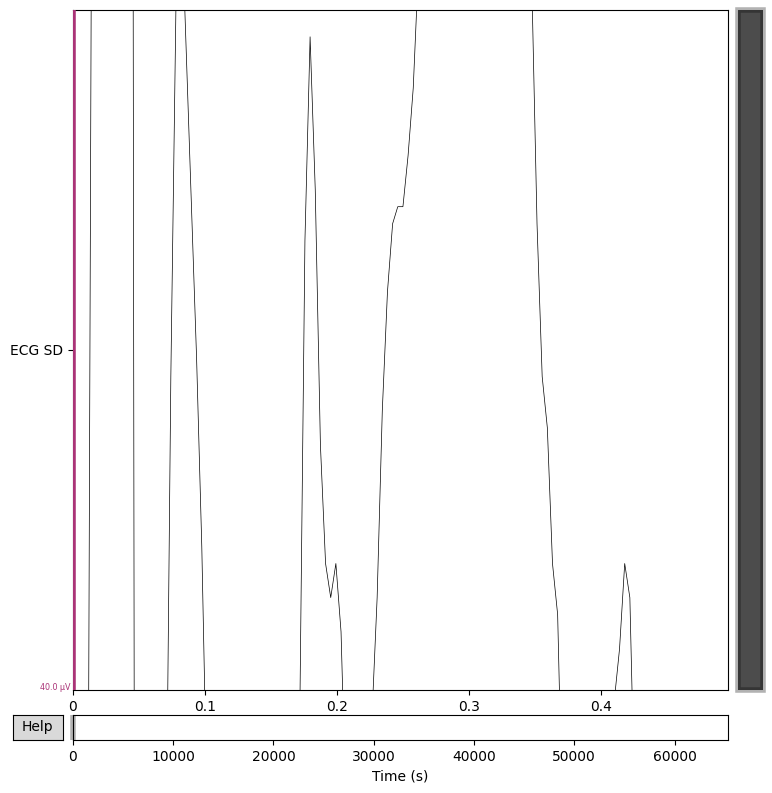

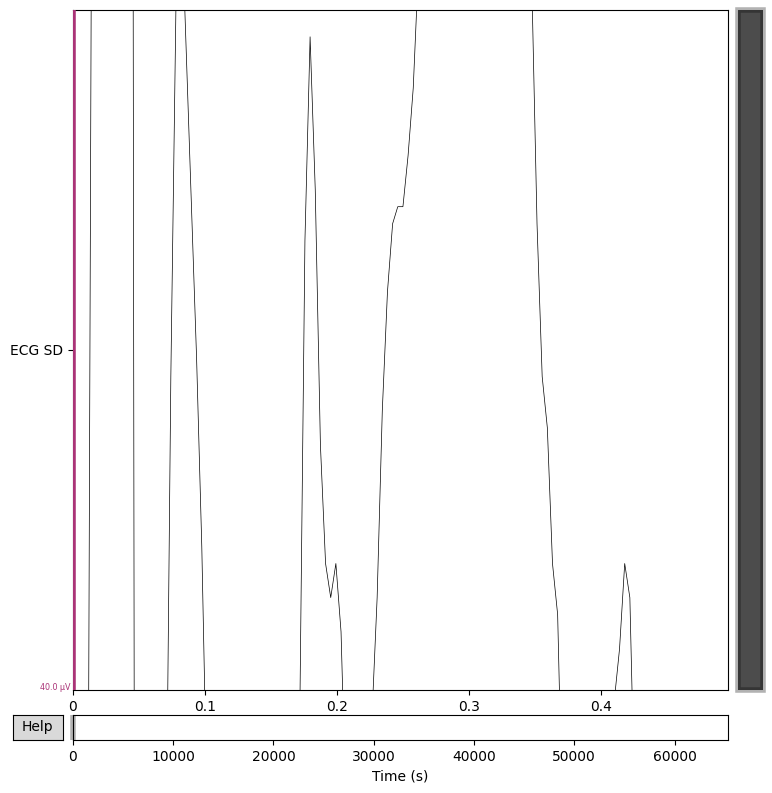

In [4]:
# visualize EEG and ECG for one patient, one run
import glob, mne

eeg_path = "/content/drive/MyDrive/MEng/6.S985/ds005873/sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-01_eeg.edf"
ecg_path = "/content/drive/MyDrive/MEng/6.S985/ds005873/sub-001/ses-01/ecg/sub-001_ses-01_task-szMonitoring_run-01_ecg.edf"

raw_eeg = mne.io.read_raw_edf(eeg_path, preload=True)
raw_ecg = mne.io.read_raw_edf(ecg_path, preload=True)

# Adjusting parameters for better readability:
# n_channels: set to a smaller number (e.g., 5-10) to avoid overcrowding
# duration: set to a shorter time (e.g., 5 seconds) to see fine details

# To adjust amplitude, change the 'eeg' value in the scalings dictionary.
# For example, 5e-5 corresponds to 50 microvolts.
# raw_eeg.plot(n_channels=1, duration=.5, scalings=dict(eeg=5e-5, ecg='auto'), title='EEG Channels (Adjusted for Readability and Amplitude)')
# raw_ecg.plot(duration= .5, scalings=dict(ecg='auto'), title='ECG Channel (Adjusted for Readability)')


# raw_eeg.compute_psd().plot()

In [5]:
# window a given file into segments

# load .edf windows for both EEG and ECG

import numpy as np
import mne

def load_edf_windows(
    eeg_edf_path: str,
    ecg_edf_path: str,
    picks=None,                 # list of channel names OR None to infer
    window_sec: float = 10.0,
    overlap_sec: float = 5.0,
    resample_hz: float | None = 256.0,   # set None to keep original
    preload: bool = True,
    verbose: bool = False
):
    raw_eeg = mne.io.read_raw_edf(eeg_edf_path, preload=preload, verbose=verbose)
    raw_ecg = mne.io.read_raw_edf(ecg_edf_path, preload=preload, verbose=verbose)

    # If channel picks not provided, keep all channels
    if picks is None:
        picks_idx = mne.pick_types(raw_eeg.info, eeg=True, ecg=True, emg=True, misc=True, stim=False, exclude=[])
    else:
        picks_idx = mne.pick_channels(raw_eeg.ch_names, include=picks)

    raw_pick_eeg = raw_eeg.copy().pick(picks_idx)
    raw_pick_ecg = raw_ecg.copy()

    # Resample for consistency (recommended for feature extraction)
    if resample_hz is not None:
        raw_pick_eeg.resample(resample_hz)

    eeg_data = raw_pick_eeg.get_data()  # shape: (n_channels, n_timepoints)
    ecg_data = raw_pick_ecg.get_data()  # shape: (n_channels, n_timepoints)
    sfreq = raw_pick_eeg.info["sfreq"]
    ch_names_eeg = raw_pick_eeg.ch_names
    ch_names_ecg = raw_pick_ecg.ch_names

    win_samp = int(window_sec * sfreq)
    hop_samp = int((window_sec - overlap_sec) * sfreq)
    if hop_samp <= 0:
        raise ValueError("overlap_sec must be < window_sec")

    n_ch, n_t = eeg_data.shape
    starts = np.arange(0, n_t - win_samp + 1, hop_samp)

    # get events for this specific patient's run
    events_path = eeg_path_to_events_path(eeg_edf_path)
    events_tsv = load_events_tsv(events_path)

    all_data = []
    for s in starts:
      eeg_window_data = eeg_data[:, s:s+win_samp]
      # Also extract windowed ECG data for consistency, assuming ecg_data is similarly structured
      ecg_window_data = ecg_data[:, s:s+win_samp]
      start_time = s/sfreq
      end_time = s/sfreq + window_sec

      # Label the window
      label_info = label_window_from_events(
          events_df=events_tsv, # Pass the pre-loaded DataFrame
          t0_sec=start_time,
          window_sec=window_sec
      )

      X = {
          'eeg_data': eeg_window_data, # Store only the current window's EEG data
          'ecg_data': ecg_window_data, # Store the current window's ECG data
          'start_time': start_time,
          'end_time': end_time,
          'label': label_info['label'] # Add the label
           }

      all_data.append(X)

    # Return the list of window dictionaries, sfreq, and channel names once
    return all_data, sfreq, ch_names_eeg, ch_names_ecg

In [6]:
import os, json, re
import pandas as pd
import numpy as np

EVENTS_JSON = "/content/drive/MyDrive/MEng/6.S985/ds005873/events.json"

def eeg_path_to_events_path(eeg_path: str) -> str:
    """
    Converts .../ses-01/eeg/<stem>_eeg.edf  ->  .../ses-01/eeg/<stem>_events.tsv
    where <stem> = sub-XXX_ses-01_task-..._run-YY
    """
    events_path = eeg_path.replace("_eeg.edf", "_events.tsv")
    return events_path

# returns dictionary of {'bckg': description of bckg, etc. for all event types}
def load_eventtype_levels(events_json_path=EVENTS_JSON):
    """
    Returns dict like {"bckg": "...", "impd": "...", "sz_foc": "...", ...}
    """
    with open(events_json_path, "r") as f:
        meta = json.load(f)
    return meta.get("eventType", {}).get("Levels", {})

# sz_types is set of sz types, non_sz is non_sz set (impd and bckg)
def build_sz_and_nonsz_sets(eventtype_levels):
    """
    Rule from your events.json:
      - non-seizure: bckg, impd
      - seizure: everything else in Levels
    """
    non_sz = {"bckg", "impd"}
    all_types = set(eventtype_levels.keys())
    sz_types = all_types - non_sz
    return sz_types, non_sz

SZ_TYPES, NON_SZ_TYPES = build_sz_and_nonsz_sets(load_eventtype_levels(EVENTS_JSON))
# print("Non-seizure types:", NON_SZ_TYPES)
# print("Example seizure types:", sorted(list(SZ_TYPES))[:10])

def eeg_path_to_events_path(eeg_path):
    """
    ds005873 structure:
      .../sub-XXX/ses-YY/eeg/<stem>_eeg.edf
    events file:
      .../sub-XXX/ses-YY/eeg/<stem>_events.tsv
    """
    # swap _eeg.edf -> _events.tsv
    return eeg_path.replace("_eeg.edf", "_events.tsv")

def load_events_tsv(events_path):
    """
    Load events TSV, coerce onset/duration numeric, add end column.
    """
    ev = pd.read_csv(events_path, sep="\t")
    ev["onset"] = pd.to_numeric(ev["onset"], errors="coerce")
    ev["duration"] = pd.to_numeric(ev["duration"], errors="coerce")
    ev = ev.dropna(subset=["onset", "duration"])
    ev["end"] = ev["onset"] + ev["duration"]
    ev["eventType"] = ev["eventType"].astype(str).str.strip()
    return ev

# returns something like ['impd', 'impd'] if 2 impd events occured in time window
def overlapping_eventtypes(ev, t0_sec, window_sec):
    """
    Return list of eventTypes whose [onset,end] overlaps [t0, t1].
    Overlap condition: onset < t1 and end > t0
    """
    t0 = float(t0_sec)
    t1 = t0 + float(window_sec)
    m = (ev["onset"] < t1) & (ev["end"] > t0)
    return ev.loc[m, "eventType"].tolist()

# calls load_events_tsv and overlapping_eventtypes
def label_window_from_events(events_path=None, events_df=None, t0_sec=0, window_sec=0, sz_types=SZ_TYPES, non_sz_types=NON_SZ_TYPES):
    """
    Label seizure if ANY overlapping eventType is in sz_types.
    Otherwise nonseizure.

    Also returns:
      - overlap_eventTypes_all: all overlapping event types (including bckg/impd)
      - overlap_eventTypes_sz: only seizure-like overlapping event types
      - n_event_overlap_all / n_event_overlap_sz
    """
    if events_df is not None:
        ev = events_df
        n_events_in_file = len(events_df)
    elif events_path and os.path.exists(events_path):
        ev = load_events_tsv(events_path)
        n_events_in_file = len(ev)
    else:
        return {
            "label": "no_events_file",
            "overlap_eventTypes_all": "",
            "overlap_eventTypes_sz": "",
            "n_event_overlap_all": 0,
            "n_event_overlap_sz": 0,
            "n_events_in_file": 0,
        }

    # list of events that overlapped, incl both sz and non-sz
    overlapped = overlapping_eventtypes(ev, t0_sec, window_sec)

    overlapped_set = set(overlapped)

    overlapped_sz = sorted([e for e in overlapped_set if e in sz_types])

    label = "seizure" if len(overlapped_sz) > 0 else "nonseizure"

    return {
        "label": label,
        "overlap_eventTypes_all": ",".join(sorted(overlapped_set)) if overlapped_set else "",
        "overlap_eventTypes_sz": ",".join(overlapped_sz), # set of sz types
        "n_event_overlap_all": int(len(overlapped_set)), # num of unique events
        "n_event_overlap_sz": int(len(overlapped_sz)), # num unique sz events
        "n_events_in_file": int(n_events_in_file), # num events in ev
    }

# eeg_path = "/content/drive/MyDrive/MEng/6.S985/ds005873/sub-001/ses-01/eeg/sub-001_ses-01_task-szMonitoring_run-01_eeg.edf"
events_path = eeg_path_to_events_path(eeg_path)

# labeled_window = label_window_from_events(events_path=events_path, t0_sec=0, window_sec=20)
# print(labeled_window)

In [7]:
# make sz and non-sz type set
EVENTS_JSON = "/content/drive/MyDrive/MEng/6.S985/ds005873/events.json"
eeg_path = "/content/drive/MyDrive/MEng/6.S985/ds005873/sub-031/ses-01/eeg/sub-031_ses-01_task-szMonitoring_run-01_eeg.edf"
ecg_path = "/content/drive/MyDrive/MEng/6.S985/ds005873/sub-031/ses-01/ecg/sub-031_ses-01_task-szMonitoring_run-01_ecg.edf"

eeg_path = "/content/drive/MyDrive/MEng/6.S985/ds005873/sub-031/ses-01/eeg/sub-031_ses-01_task-szMonitoring_run-01_eeg.edf"
ecg_path = "/content/drive/MyDrive/MEng/6.S985/ds005873/sub-031/ses-01/ecg/sub-031_ses-01_task-szMonitoring_run-01_ecg.edf"

levels = load_eventtype_levels(EVENTS_JSON)
sz_types, non_sz_types = build_sz_and_nonsz_sets(levels)

current_eeg_windowed, sfreq_eeg, ch_names_eeg, ch_names_ecg = load_edf_windows(eeg_path, ecg_path)

Sampling frequency of the instance is already 256.0, returning unmodified.


In [24]:
len(current_eeg_windowed[0]['eeg_data'][1])
current_eeg_windowed[14]['label']
# 11595 is seizure, 4650 for run 3
# for run 5, 12194

'nonseizure'

In [11]:
# To visualize a windowed segment using MNE, first need to convert NumPy array
# data into an mne.io.RawArray object. This requires an mne.Info object,
# which contains essential metadata like sampling frequency (sfreq) and channel names (ch_names).

window_num = 14
print(current_eeg_windowed[window_num]['label'])
raw_data = current_eeg_windowed[window_num]['eeg_data']
info = mne.create_info(ch_names=ch_names_eeg, sfreq=sfreq_eeg, ch_types='eeg')

raw_eeg = mne.io.RawArray(raw_data, info)

nonseizure
Creating RawArray with float64 data, n_channels=2, n_times=2560
    Range : 0 ... 2559 =      0.000 ...     9.996 secs
Ready.


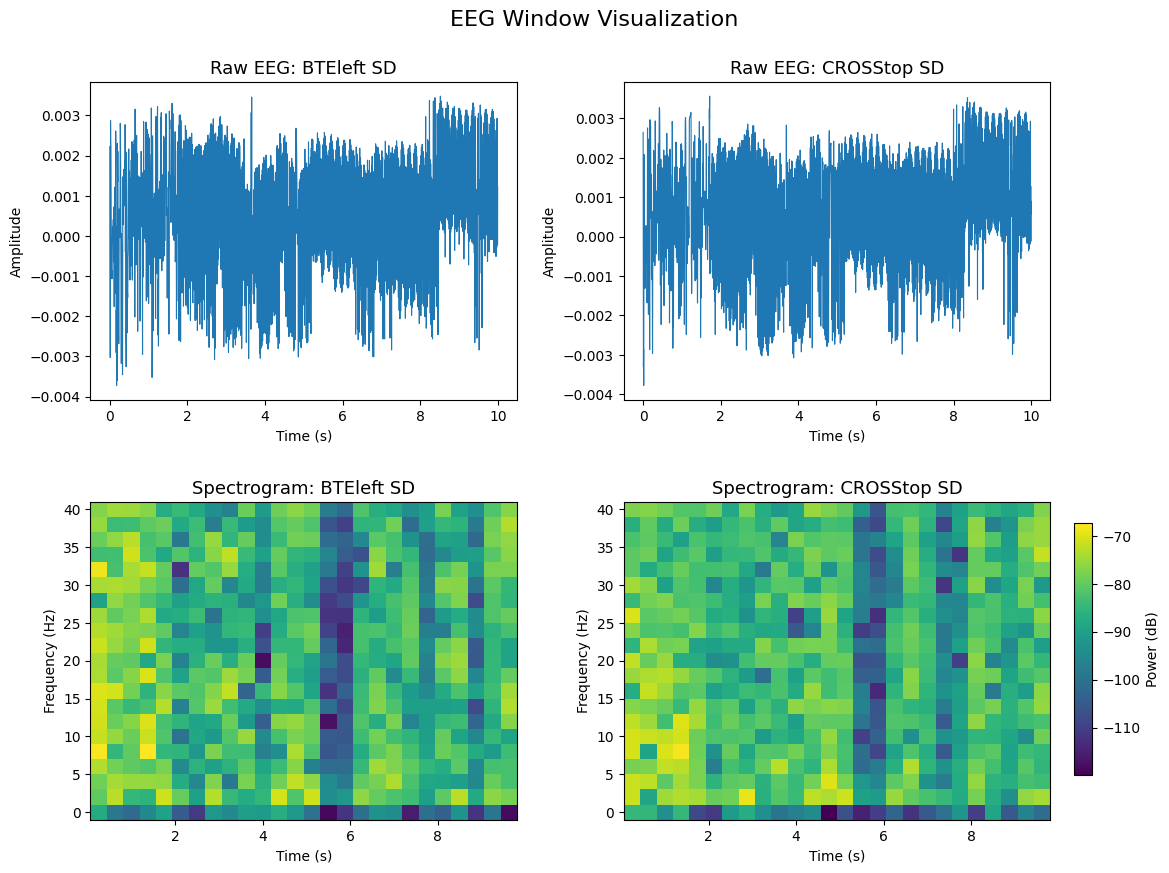

In [19]:
save_eeg_window_2x2(
    raw_data=raw_data,
    sfreq_eeg=sfreq_eeg,
    ch_names=ch_names_eeg,
    out_path=None, # set a file path here to save
    nperseg=128,
    noverlap=32,
    freq_max=40,
    raw_ylim=None # or set something fixed after inspecting your ranges
)

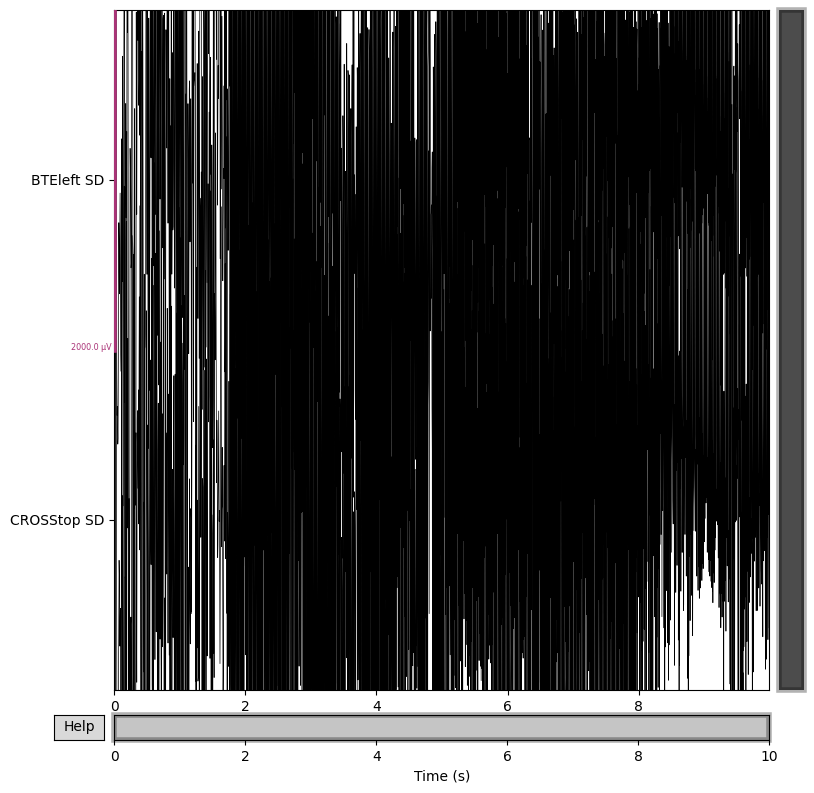

NameError: name 'plot_spectrogram' is not defined

In [12]:
# raw_eeg.plot()

raw_eeg.plot(duration=10, scalings=dict(eeg=1e-3), title='EEG Channels (Adjusted for Readability and Amplitude)')

plot_spectrogram(raw_data)

Effective window size : 1.000 (s)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Plotting power spectral density (dB=True).


[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:    4.9s finished
/tmp/ipykernel_3015/1678937571.py:6: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  reject_by_annotation=True, n_jobs=-1).plot()


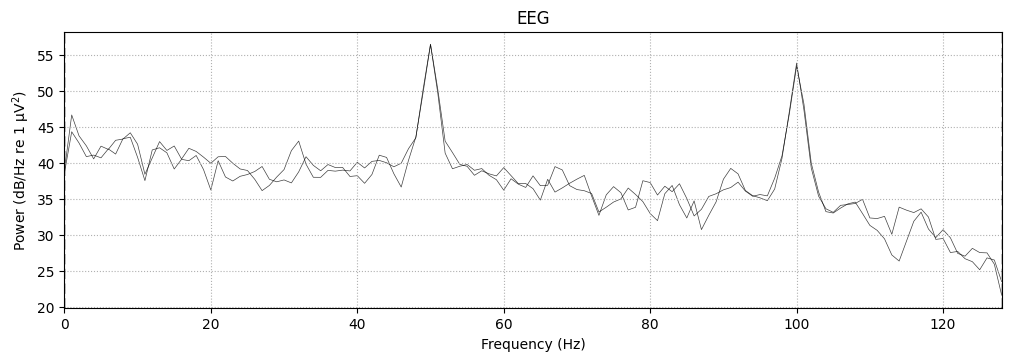

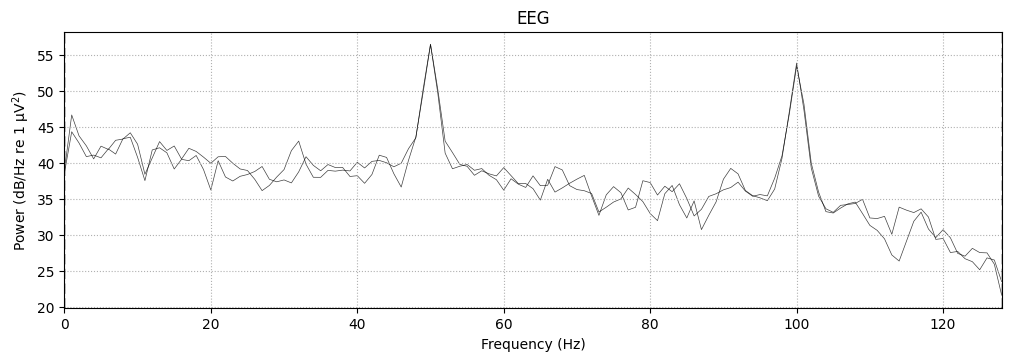

In [13]:
# Generate and plot spectrogram for EEG data
# MNE provides a convenient way to compute and plot spectrograms

mne.time_frequency.Spectrum(raw_eeg, 'auto', fmin=0, fmax=np.inf, tmin=None, tmax=None,
                            picks='all', exclude='bads', proj=False, remove_dc=True,
                            reject_by_annotation=True, n_jobs=-1).plot()



In [14]:
# spectogram

from scipy.signal import spectrogram
import matplotlib.pyplot as plt

def plot_spectrogram(raw_data):
  # window = current_eeg_windowed[12197]
  # raw_data = window['eeg_data']
  # print(window['label'])

  f, t, Sxx = spectrogram(raw_data[0], fs=sfreq_eeg)
  f2, t2, Sxx2 = spectrogram(raw_data[1], fs=sfreq_eeg) # Assuming there's a second channel to plot in the second subplot

  fig, ax = plt.subplots(2, 1, figsize=(10, 8))

  # Plot for the first channel
  mesh1 = ax[0].pcolormesh(t, f, 10 * np.log10(Sxx), shading='nearest')
  ax[0].set_ylabel('Frequency [Hz]')
  ax[0].set_xlabel('Time [sec]')
  ax[0].set_title('Spectrogram Channel 1')
  fig.colorbar(mesh1, ax=ax[0], format='%+2.0f dB')

  # Plot for the second channel
  mesh2 = ax[1].pcolormesh(t2, f2, 10 * np.log10(Sxx2), shading='nearest')
  ax[1].set_ylabel('Frequency [Hz]')
  ax[1].set_xlabel('Time [sec]')
  ax[1].set_title('Spectrogram Channel 2')
  fig.colorbar(mesh2, ax=ax[1], format='%+2.0f dB')

  plt.tight_layout()
  plt.show()

# plot_spectrogram(raw_data)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

def save_eeg_window_2x2(
    raw_data,
    sfreq_eeg,
    ch_names=None,
    out_path=None,
    nperseg=128,
    noverlap=32,
    freq_max=40,
    raw_ylim=None,
    cmap="viridis"
):
    assert raw_data.shape[0] == 2, f"Expected 2 channels, got shape {raw_data.shape}"

    if ch_names is None:
        ch_names = ["Channel 1", "Channel 2"]

    n_times = raw_data.shape[1]
    time = np.arange(n_times) / sfreq_eeg

    # Spectrograms
    f1, t1, Sxx1 = spectrogram(raw_data[0], fs=sfreq_eeg, nperseg=nperseg, noverlap=noverlap)
    f2, t2, Sxx2 = spectrogram(raw_data[1], fs=sfreq_eeg, nperseg=nperseg, noverlap=noverlap)

    Sxx1_db = 10 * np.log10(Sxx1 + 1e-12)
    Sxx2_db = 10 * np.log10(Sxx2 + 1e-12)

    keep_f1 = f1 <= freq_max
    keep_f2 = f2 <= freq_max

    f1_plot, Sxx1_plot = f1[keep_f1], Sxx1_db[keep_f1, :]
    f2_plot, Sxx2_plot = f2[keep_f2], Sxx2_db[keep_f2, :]

    vmin = min(Sxx1_plot.min(), Sxx2_plot.min())
    vmax = max(Sxx1_plot.max(), Sxx2_plot.max())

    # Bigger figure, no constrained_layout
    fig, ax = plt.subplots(2, 2, figsize=(12, 9))

    # -------- raw channel 1 --------
    ax[0, 0].plot(time, raw_data[0], linewidth=0.8)
    ax[0, 0].set_title(f"Raw EEG: {ch_names[0]}", fontsize=13)
    ax[0, 0].set_xlabel("Time (s)")
    ax[0, 0].set_ylabel("Amplitude")
    if raw_ylim is not None:
        ax[0, 0].set_ylim(raw_ylim)

    # -------- raw channel 2 --------
    ax[0, 1].plot(time, raw_data[1], linewidth=0.8)
    ax[0, 1].set_title(f"Raw EEG: {ch_names[1]}", fontsize=13)
    ax[0, 1].set_xlabel("Time (s)")
    ax[0, 1].set_ylabel("Amplitude")
    if raw_ylim is not None:
        ax[0, 1].set_ylim(raw_ylim)

    # -------- spectrogram channel 1 --------
    mesh1 = ax[1, 0].pcolormesh(
        t1, f1_plot, Sxx1_plot,
        shading="nearest",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    ax[1, 0].set_title(f"Spectrogram: {ch_names[0]}", fontsize=13)
    ax[1, 0].set_xlabel("Time (s)")
    ax[1, 0].set_ylabel("Frequency (Hz)")

    # -------- spectrogram channel 2 --------
    mesh2 = ax[1, 1].pcolormesh(
        t2, f2_plot, Sxx2_plot,
        shading="nearest",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    ax[1, 1].set_title(f"Spectrogram: {ch_names[1]}", fontsize=13)
    ax[1, 1].set_xlabel("Time (s)")
    ax[1, 1].set_ylabel("Frequency (Hz)")

    # Main title
    fig.suptitle("EEG Window Visualization", fontsize=16)

    # Manually create space: right for colorbar, top for suptitle, vertical gap between rows
    fig.subplots_adjust(
        left=0.08,
        right=0.88,
        top=0.90,
        bottom=0.08,
        wspace=0.25,
        hspace=0.32
    )

    # Dedicated colorbar axis to the right of the bottom row
    cax = fig.add_axes([0.90, 0.13, 0.015, 0.28])  # [left, bottom, width, height]
    cbar = fig.colorbar(mesh2, cax=cax)
    cbar.set_label("Power (dB)")

    if out_path is not None:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

In [17]:
window_num = 14
raw_data = current_eeg_windowed[window_num]['eeg_data']
label = current_eeg_windowed[window_num]['label']

save_eeg_window_2x2(
    raw_data=raw_data,
    sfreq_eeg=sfreq_eeg,
    ch_names=ch_names_eeg,
    out_path='/content/drive/MyDrive/MEng/6.S985/images/pt1run1.png', # set a file path here to save
    nperseg=128,
    noverlap=32,
    freq_max=40,
    raw_ylim=None # or set something fixed after inspecting your ranges
)

In [18]:
import os, glob

# get all filepaths

base_path = "/content/drive/MyDrive/MEng/6.S985/ds005873/sub-"
eeg_middle_part = "/ses-01/eeg/sub-"
ecg_middle_part = "/ses-01/ecg/sub-"
common_task_prefix = "_ses-01_task-szMonitoring_"
eeg_file_extension = "_eeg.edf"
ecg_file_extension = "_ecg.edf"

all_eeg_paths = []
all_ecg_paths = []

for i in range(1, 126):
  pt_num = str(i).zfill(3)

  # Construct EEG path pattern with wildcard for run number
  eeg_pattern = os.path.join(
      base_path + pt_num + eeg_middle_part + pt_num + common_task_prefix + 'run-*' + eeg_file_extension
  )
  # Find all matching EEG files
  all_eeg_paths.extend(glob.glob(eeg_pattern))

  # Construct ECG path pattern with wildcard for run number
  ecg_pattern = os.path.join(
      base_path + pt_num + ecg_middle_part + pt_num + common_task_prefix + 'run-*' + ecg_file_extension
  )
  # Find all matching ECG files
  all_ecg_paths.extend(glob.glob(ecg_pattern))

print(f"Total EEG paths collected: {len(all_eeg_paths)}")
print(f"Total ECG paths collected: {len(all_ecg_paths)}")

print("\nFirst 5 EEG paths (dynamic runs):")
for path in all_eeg_paths[:5]:
    print(path)

print("\nFirst 5 ECG paths (dynamic runs):")
for path in all_ecg_paths[:5]:
    print(path)

# 2850 EEG paths total

KeyboardInterrupt: 

In [ ]:
import os
import re
import glob
import json
import random
from collections import defaultdict

import numpy as np

# =========================================================
# CONFIG
# =========================================================
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

BASE_DS_PATH = "/content/drive/MyDrive/MEng/6.S985/ds005873"
OUT_BASE = "/content/drive/MyDrive/MEng/6.S985/mmai-data"

# For 40 total patients, use 28/6/6
N_TOTAL_PATIENTS = 40
N_TRAIN_PATIENTS = 28
N_VAL_PATIENTS = 6
N_TEST_PATIENTS = 6

RUNS_PER_PATIENT = 2
WINDOWS_PER_RUN = 8
TARGET_SZ_PER_RUN = 4
TARGET_NONSZ_PER_RUN = 4

WINDOW_SEC = 10.0
OVERLAP_SEC = 5.0
RESAMPLE_HZ = 256.0

# To reduce near-duplicate overlapping windows:
# with 10 sec windows and 5 sec overlap, adjacent windows overlap a lot.
# min_gap=2 means do not choose immediately adjacent window indices.
MIN_INDEX_GAP = 2

QUESTION_TEXT = "What is the dataset label for this ear-EEG window?"


# =========================================================
# HELPERS: paths / parsing
# =========================================================
def parse_patient_id(path: str) -> str:
    m = re.search(r"/sub-(\d{3})/", path)
    if not m:
        raise ValueError(f"Could not parse patient id from path: {path}")
    return m.group(1)

def parse_run_id(path: str) -> str:
    m = re.search(r"_run-(\d+)_", path)
    if not m:
        raise ValueError(f"Could not parse run id from path: {path}")
    return m.group(1)

def collect_matched_runs(base_ds_path: str):
    """
    Build patient -> list of matched (eeg_path, ecg_path, run_id)
    using only runs that have both EEG and ECG files.
    """
    eeg_glob = os.path.join(
        base_ds_path,
        "sub-*", "ses-01", "eeg", "*_task-szMonitoring_run-*_eeg.edf"
    )
    ecg_glob = os.path.join(
        base_ds_path,
        "sub-*", "ses-01", "ecg", "*_task-szMonitoring_run-*_ecg.edf"
    )

    eeg_paths = sorted(glob.glob(eeg_glob))
    ecg_paths = sorted(glob.glob(ecg_glob))

    # index ECG by (patient, run)
    ecg_map = {}
    for p in ecg_paths:
        patient = parse_patient_id(p)
        run = parse_run_id(p)
        ecg_map[(patient, run)] = p

    patient_runs = defaultdict(list)
    for eeg_path in eeg_paths:
        patient = parse_patient_id(eeg_path)
        run = parse_run_id(eeg_path)
        ecg_path = ecg_map.get((patient, run))
        if ecg_path is not None:
            patient_runs[patient].append({
                "patient_id": patient,
                "run_id": run,
                "eeg_path": eeg_path,
                "ecg_path": ecg_path,
            })

    # sort runs per patient by numeric run id
    for patient in patient_runs:
        patient_runs[patient] = sorted(
            patient_runs[patient],
            key=lambda x: int(x["run_id"])
        )

    return patient_runs


# =========================================================
# HELPERS: patient split
# =========================================================
def sample_patient_split(patient_runs: dict):
    """
    Sample patients that have at least RUNS_PER_PATIENT matched runs.
    """
    eligible_patients = [
        p for p, runs in patient_runs.items()
        if len(runs) >= RUNS_PER_PATIENT
    ]

    if len(eligible_patients) < N_TOTAL_PATIENTS:
        raise ValueError(
            f"Only {len(eligible_patients)} eligible patients found, "
            f"but requested {N_TOTAL_PATIENTS}."
        )

    sampled_patients = random.sample(eligible_patients, N_TOTAL_PATIENTS)
    random.shuffle(sampled_patients)

    train_patients = sampled_patients[:N_TRAIN_PATIENTS]
    val_patients = sampled_patients[N_TRAIN_PATIENTS:N_TRAIN_PATIENTS + N_VAL_PATIENTS]
    test_patients = sampled_patients[N_TRAIN_PATIENTS + N_VAL_PATIENTS:
                                     N_TRAIN_PATIENTS + N_VAL_PATIENTS + N_TEST_PATIENTS]

    return {
        "train": train_patients,
        "val": val_patients,
        "test": test_patients,
    }


# =========================================================
# HELPERS: run sampling
# =========================================================
def choose_runs_for_patient(runs_for_patient, k=2):
    if len(runs_for_patient) < k:
        raise ValueError("Patient does not have enough runs.")
    return random.sample(runs_for_patient, k)


# =========================================================
# HELPERS: window sampling
# =========================================================
def sample_with_gap(indices, k, min_gap=2):
    """
    Randomly choose up to k indices such that chosen indices differ
    by at least min_gap.
    """
    indices = sorted(indices)
    if len(indices) == 0:
        return []

    shuffled = indices.copy()
    random.shuffle(shuffled)

    chosen = []
    for idx in shuffled:
        if all(abs(idx - c) >= min_gap for c in chosen):
            chosen.append(idx)
        if len(chosen) == k:
            break

    return sorted(chosen)

def choose_window_indices(windowed_data, total_k=8, target_sz=4, target_nonsz=4, min_gap=2):
    """
    Prefer 4 seizure + 4 nonseizure. Backfill from whichever class remains.
    """
    seizure_idx = [i for i, w in enumerate(windowed_data) if w["label"] == "seizure"]
    nonsz_idx = [i for i, w in enumerate(windowed_data) if w["label"] == "nonseizure"]

    chosen_sz = sample_with_gap(seizure_idx, min(target_sz, len(seizure_idx)), min_gap=min_gap)
    chosen_nonsz = sample_with_gap(nonsz_idx, min(target_nonsz, len(nonsz_idx)), min_gap=min_gap)

    chosen = chosen_sz + chosen_nonsz
    chosen = sorted(set(chosen))

    remaining_needed = total_k - len(chosen)
    if remaining_needed > 0:
        remaining_pool = sorted(set(seizure_idx + nonsz_idx) - set(chosen))
        backfill = sample_with_gap(remaining_pool, remaining_needed, min_gap=min_gap)
        chosen = sorted(set(chosen + backfill))

    # If still too many due to set/spacing quirks, trim
    if len(chosen) > total_k:
        chosen = chosen[:total_k]

    return chosen


# =========================================================
# HELPERS: output dirs / JSONL
# =========================================================
def ensure_dirs(base_out):
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(base_out, split, "images"), exist_ok=True)

def image_filename(patient_id, run_id, window_idx):
    return f"sub-{patient_id}_run-{run_id}_window-{window_idx:05d}.png"

def rel_image_path(split, filename):
    return f"{split}/images/{filename}"


# =========================================================
# MAIN BUILD
# =========================================================
def build_dataset():
    ensure_dirs(OUT_BASE)

    patient_runs = collect_matched_runs(BASE_DS_PATH)
    split_map = sample_patient_split(patient_runs)

    summary = {
        "seed": RANDOM_SEED,
        "n_total_patients": N_TOTAL_PATIENTS,
        "splits": {k: len(v) for k, v in split_map.items()},
        "runs_per_patient": RUNS_PER_PATIENT,
        "windows_per_run": WINDOWS_PER_RUN,
        "target_sz_per_run": TARGET_SZ_PER_RUN,
        "target_nonsz_per_run": TARGET_NONSZ_PER_RUN,
        "examples": {"train": 0, "val": 0, "test": 0},
        "class_counts": {
            "train": {"seizure": 0, "nonseizure": 0},
            "val": {"seizure": 0, "nonseizure": 0},
            "test": {"seizure": 0, "nonseizure": 0},
        }
    }

    for split in ["train", "val", "test"]:
        records = []

        for patient_id in split_map[split]:
            runs = choose_runs_for_patient(patient_runs[patient_id], k=RUNS_PER_PATIENT)

            for run_info in runs:
                eeg_path = run_info["eeg_path"]
                ecg_path = run_info["ecg_path"]
                run_id = run_info["run_id"]

                try:
                    windowed_data, sfreq_eeg, ch_names_eeg, ch_names_ecg = load_edf_windows(
                        eeg_edf_path=eeg_path,
                        ecg_edf_path=ecg_path,
                        window_sec=WINDOW_SEC,
                        overlap_sec=OVERLAP_SEC,
                        resample_hz=RESAMPLE_HZ,
                        preload=True,
                        verbose=False
                    )
                except Exception as e:
                    print(f"[WARN] Failed loading patient {patient_id}, run {run_id}: {e}")
                    continue

                chosen_indices = choose_window_indices(
                    windowed_data,
                    total_k=WINDOWS_PER_RUN,
                    target_sz=TARGET_SZ_PER_RUN,
                    target_nonsz=TARGET_NONSZ_PER_RUN,
                    min_gap=MIN_INDEX_GAP
                )

                if len(chosen_indices) == 0:
                    print(f"[WARN] No usable windows for patient {patient_id}, run {run_id}")
                    continue

                for window_idx in chosen_indices:
                    window = windowed_data[window_idx]
                    raw_data = window["eeg_data"]
                    label = window["label"]

                    fname = image_filename(patient_id, run_id, window_idx)
                    abs_img_path = os.path.join(OUT_BASE, split, "images", fname)

                    try:
                        save_eeg_window_2x2(
                            raw_data=raw_data,
                            sfreq_eeg=sfreq_eeg,
                            ch_names=ch_names_eeg,
                            out_path=abs_img_path,
                            nperseg=128,
                            noverlap=32,
                            freq_max=40,
                            raw_ylim=None
                        )
                    except Exception as e:
                        print(f"[WARN] Failed saving image for patient {patient_id}, run {run_id}, window {window_idx}: {e}")
                        continue

                    records.append({
                        "image": rel_image_path(split, fname),
                        "question": QUESTION_TEXT,
                        "answer": label,
                        "patient_id": patient_id,
                        "run_id": run_id,
                        "window_idx": window_idx,
                        "start_time": float(window["start_time"]),
                        "end_time": float(window["end_time"]),
                    })

                    summary["examples"][split] += 1
                    if label in summary["class_counts"][split]:
                        summary["class_counts"][split][label] += 1

        # write split jsonl
        jsonl_path = os.path.join(OUT_BASE, split, "data.jsonl")
        with open(jsonl_path, "w") as f:
            for row in records:
                f.write(json.dumps(row) + "\n")

        print(f"{split}: wrote {len(records)} examples to {jsonl_path}")

    # write split manifest
    with open(os.path.join(OUT_BASE, "summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    with open(os.path.join(OUT_BASE, "patient_split.json"), "w") as f:
        json.dump(split_map, f, indent=2)

    print("\nDone.")
    print(json.dumps(summary, indent=2))


# Run it
build_dataset()

Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the instance is already 256.0, returning unmodified.
Sampling frequency of the